# EDA New (Processed Taxi Data)

This notebook follows the 8-step EDA workflow:
1. Profile each attribute
2. Perform statistical analysis
3. Assess data quality
4. Identify target candidates
5. Visualize data
6. Study correlations
7. Simulate manual solutions
8. Identify transformations and extra data


In [ ]:
from pathlib import Path
import sys
import importlib

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)

# Resolve project root and load notebooks/exploratory/eda_new.py reliably in Jupyter.
cwd = Path.cwd().resolve()
root_candidates = [cwd, cwd.parent, cwd.parent.parent]
project_root = next(
    (p for p in root_candidates if (p / 'notebooks' / 'exploratory' / 'eda_new.py').exists()),
    cwd,
)

eda_dir = (project_root / 'notebooks' / 'exploratory').resolve()
if str(eda_dir) not in sys.path:
    sys.path.insert(0, str(eda_dir))

import eda_new as eda  # noqa: E402
eda = importlib.reload(eda)

assert hasattr(eda, 'profile_attributes'), 'eda_new.py loaded, but profile_attributes was not found.'


In [6]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data' / 'processed').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.parent

DATA_PATH =PROJECT_ROOT / 'data' / 'processed'

df = pd.read_parquet(DATA_PATH)
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns')
df.head()

Shape: 98,309 rows x 29 columns


,VendorID,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,pickup_location_id,dropoff_location_id,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee,trip_duration_seconds,vehicle_type,pickup_year,pickup_month,pickup_day,pickup_hour,pickup_dayofweek,pickup_weekday,time_of_day
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1,0.97,1,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00,NaN,506.0,yellow,2023,1,1,0,6,False,night
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1,1.10,1,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00,NaN,379.0,yellow,2023,1,1,0,6,False,night
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1,2.51,1,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00,NaN,765.0,yellow,2023,1,1,0,6,False,night
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0,1.90,1,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25,NaN,577.0,yellow,2023,1,1,0,6,False,night
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1,1.43,1,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00,NaN,650.0,yellow,2023,1,1,0,6,False,night


## 1) Profile Each Attribute

In [7]:
attr_profile = eda.profile_attributes(df)
display(attr_profile)


,column,dtype,inferred_type,distribution,n_unique,missing_pct,non_null_rows
0,pickup_weekday,bool,boolean,discrete,2,0.000,98309
1,store_and_fwd_flag,object,categorical,n/a,2,0.000,98309
2,vehicle_type,object,categorical,n/a,1,0.000,98309
3,Airport_fee,float64,categorical-discrete,discrete,3,50.314,48846
4,RatecodeID,int64,categorical-discrete,discrete,7,0.000,98309
5,VendorID,int64,categorical-discrete,discrete,2,0.000,98309
6,airport_fee,float64,categorical-discrete,discrete,2,49.686,49463
7,congestion_surcharge,float64,categorical-discrete,discrete,4,0.000,98309
8,improvement_surcharge,float64,categorical-discrete,discrete,4,0.000,98309
9,mta_tax,float64,categorical-discrete,discrete,5,0.000,98309


## 2) Perform Statistical Analysis

In [8]:
desc, quantiles, missing_pct = eda.statistical_analysis(df)

print('Descriptive statistics (numeric):')
display(desc.round(4))

print('Quantile statistics (numeric):')
display(quantiles.round(4))

print('Missing values (%):')
display(missing_pct.round(3).rename('missing_pct').to_frame())


Descriptive statistics (numeric):


,count,mean,std,min,25%,50%,75%,max
VendorID,98309.0,1.7551,0.4301,1.00,2.0,2.00,2.00,2.00
passenger_count,98309.0,1.4862,0.9551,0.00,1.0,1.00,2.00,6.00
trip_distance,98309.0,4.0005,4.9542,0.00,1.1,2.00,4.40,78.45
RatecodeID,98309.0,1.9789,9.0943,1.00,1.0,1.00,1.00,99.00
pickup_location_id,98309.0,160.3863,65.4334,1.00,119.0,161.00,230.00,265.00
dropoff_location_id,98309.0,158.6851,72.6459,1.00,107.0,161.00,233.00,265.00
payment_type,98309.0,1.2496,0.5232,1.00,1.0,1.00,1.00,4.00
fare_amount,98309.0,21.2232,20.2764,0.00,8.6,13.50,24.70,500.00
extra,98309.0,1.1569,1.6053,0.00,0.0,1.00,2.50,11.75
mta_tax,98309.0,0.4895,0.0730,-0.50,0.5,0.50,0.50,4.00


Quantile statistics (numeric):


,0.01,0.05,0.25,0.50,0.75,0.95,0.99
VendorID,1.0,1.00,2.0,2.00,2.00,2.000,2.0000
passenger_count,0.0,1.00,1.0,1.00,2.00,4.000,5.0000
trip_distance,0.0,0.49,1.1,2.00,4.40,17.150,20.7000
RatecodeID,1.0,1.00,1.0,1.00,1.00,2.000,5.0000
pickup_location_id,13.0,48.00,119.0,161.00,230.00,261.000,264.0000
dropoff_location_id,4.0,41.00,107.0,161.00,233.00,262.000,264.0000
payment_type,1.0,1.00,1.0,1.00,1.00,2.000,4.0000
fare_amount,3.7,5.80,8.6,13.50,24.70,70.000,87.0000
extra,0.0,0.00,0.0,1.00,2.50,5.000,6.7500
mta_tax,0.0,0.50,0.5,0.50,0.50,0.500,0.5000


Missing values (%):


,missing_pct
Airport_fee,50.314
airport_fee,49.686
dropoff_datetime,0.000
pickup_datetime,0.000
VendorID,0.000
RatecodeID,0.000
store_and_fwd_flag,0.000
pickup_location_id,0.000
dropoff_location_id,0.000
payment_type,0.000


## 3) Assess Data Quality

In [9]:
quality_df = eda.assess_data_quality(df)
duplicates = int(df.duplicated().sum())

display(quality_df)
print(f'Duplicate rows: {duplicates}')


,column,iqr_outlier_pct,zscore_outlier_pct,coef_variation,rounded_integer_pct,rounded_half_pct,noise_type
0,total_amount,12.743,1.150,0.838,8.296,13.543,outliers
1,trip_distance,12.259,2.346,1.238,4.732,7.941,outliers
2,fare_amount,9.815,1.381,0.955,15.378,26.358,outliers
3,tip_amount,6.869,1.377,1.283,42.912,46.189,outliers
4,passenger_count,5.714,2.002,0.643,100.000,100.000,outliers
5,trip_duration_seconds,5.141,0.123,2.856,100.000,100.000,"outliers, possible_rounding"
6,extra,1.062,1.530,1.388,77.555,98.142,low_noise
7,payment_type,0.000,1.903,0.419,100.000,100.000,low_noise
8,dropoff_location_id,0.000,0.000,0.458,100.000,100.000,possible_rounding
9,pickup_location_id,0.000,0.000,0.408,100.000,100.000,possible_rounding


Duplicate rows: 0


## 4) Identify Target Candidates

In [10]:
targets = eda.identify_target_candidates(df)
display(targets)


,candidate_target,task_type,reason
0,total_amount,regression,Direct business KPI for trip revenue prediction
1,trip_duration_seconds,regression,Useful for ETA or trip-time prediction
2,fare_amount,regression,Core monetary component of each trip
3,payment_type,classification,Discrete label for payment behavior modeling
4,dropoff_location_id,multiclass_classification,Destination prediction from pickup/time context


## 5) Visualize Data

Saved generated figures to: C:\Users\user\Documents\Winter26\EnterPri\Project\nyc-mobility-analysis\notebooks\exploratory\figures\eda_new


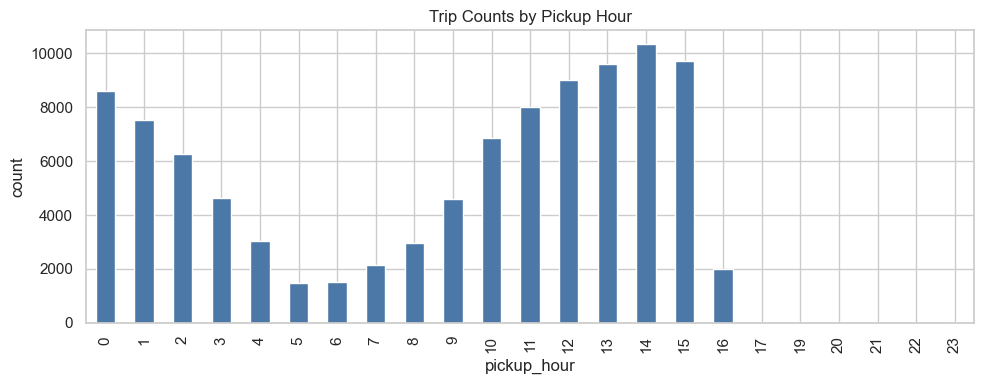

In [11]:
corr, reject_cols, high_corr_df = eda.study_correlations(df, threshold=0.9)
fig_dir = project_root / 'notebooks' / 'exploratory' / 'figures' / 'eda_new'
eda.visualize_data(df, corr, fig_dir)
print(f'Saved generated figures to: {fig_dir}')

# Quick inline visual checks
if 'pickup_hour' in df.columns:
    plt.figure(figsize=(10, 4))
    df['pickup_hour'].value_counts().sort_index().plot(kind='bar', color='#4C78A8')
    plt.title('Trip Counts by Pickup Hour')
    plt.xlabel('pickup_hour')
    plt.ylabel('count')
    plt.tight_layout()
    plt.show()


## 6) Study Correlations

In [12]:
display(high_corr_df)
print('Suggested variables to reject (|corr| >= 0.9):')
print(reject_cols)


,feature_a,feature_b,corr
1,pickup_year,pickup_month,0.9974
0,fare_amount,total_amount,0.9790


Suggested variables to reject (|corr| >= 0.9):
['pickup_month', 'total_amount']


## 7) Simulate Manual Solutions

In [13]:
manual_df = eda.simulate_manual_solution(df)
display(manual_df)


,manual_solution_playbook
0,Estimate expected demand manually by averaging...
1,Estimate fare manually using fare_amount basel...
2,Flag anomalous trips manually when trip_durati...
3,Assign service zones manually by grouping high...


## 8) Identify Transformations / Extra Data

In [14]:
transform_df = eda.identify_transformations(df, high_corr_df)
display(transform_df)


,transformation,why
0,Cyclical encoding for pickup_hour,Preserves circular time relationships (23 and ...
1,Cyclical encoding for pickup_dayofweek,Captures weekly periodicity in travel behavior.
2,"log1p transform for skewed columns (VendorID, ...",Reduces heavy-tail effects and stabilizes mode...
3,Drop or combine high-correlation variables (fa...,Reduces multicollinearity and feature redundancy.
4,Robust scaling for fare/distance/duration feat...,Mitigates impact of outliers.
5,Frequency encoding for high-cardinality locati...,Retains signal while controlling feature dimen...
6,Add weather and special-event features,External context often explains demand and dur...
